In [226]:
import numpy as np

from matplotlib import pyplot as plt

from sklearn import cluster

In [227]:
cluster.KMeans

sklearn.cluster._kmeans.KMeans

/home/pat/.cache/pypoetry/virtualenvs/xaikd-bYmevfGI-py3.11/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


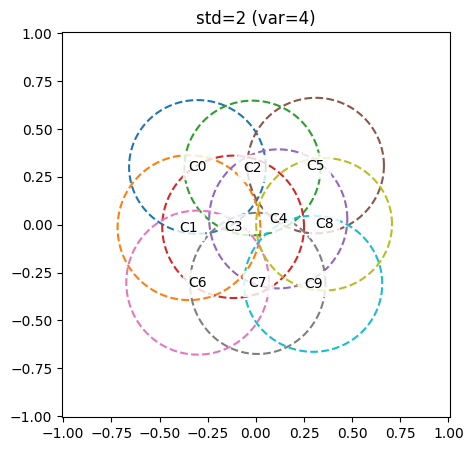

In [271]:
def generate(std=0.1, n=500, nblobs=10, seed=1):
    np.random.seed(seed)
    
    scale = 10
    
    points = scale*np.random.rand(100*n, 2) - scale / 2
    
    
    kmean = cluster.KMeans(nblobs, random_state=seed)
    
    kmean.fit(points)
    
    mu = kmean.cluster_centers_
    
    _dix = np.argsort(np.linalg.norm(mu - [-scale//2, scale//2], axis=1))
    mu = mu[_dix, :]

    arr_x = []

    arr_targets = []
    
    for bix in range(nblobs):
        _mu = mu[bix, :]
        
        arr_x.append(
            _mu + std*np.random.randn(n, 2) 
        )
        
        arr_targets.append([bix]*n)
        
    x = np.vstack(arr_x)
    
    x = x / np.max(np.abs(x))
    
    y = np.concatenate(arr_targets)


    x = (x - np.mean(x, axis=0)) 
    
    arr_pairs = []
    arr_dist = []
    
    for c1 in range(nblobs-1):
        for c2 in range(c1+1, nblobs):
            dist = np.linalg.norm(mu[c1, :] - mu[c2, :])
            arr_dist.append(dist)
            arr_pairs.append((c1, c2))
            
    arr_pairs = np.array(arr_pairs)
    arr_dist = np.array(arr_dist)
    indices = np.argsort(arr_dist)

    arr_pairs = arr_pairs[indices]
    arr_dist = arr_dist[indices]
    
    
    return x, y, arr_pairs, arr_dist
    

    
def ano(std):
    
    X, y, _, _ = generate(std=std)
    
    
    theta = np.linspace( 0 , 2 * np.pi , 150 )
    
    plt.figure(figsize=(5, 5))
    plt.title(f"std={std} (var={std**2})")
    vmax = np.max(np.abs(X))
    
    plt.ylim([-vmax, vmax])
    plt.xlim([-vmax, vmax])
    for i in range(len(set(y))):
        _x = X[y==i]
        _y = y[y==i]
        _mu = np.mean(_x, axis=0)
        
        std = np.std(_x, axis=0)
        radius = 2*std
        
        a = radius[0] * np.cos( theta )
        b = radius[1] * np.sin( theta )
        plt.plot(
            _mu[0] + a,
            _mu[1] + b,
            ls="--",
            alpha=1
        )

        plt.text(
            *_mu, f"C{i}", ha="center",  va="center", 
#             color=plt.gca().lines[-1].get_color(),
            bbox=dict(facecolor='white', ec="white", ls=None, alpha=0.8)
        )
ano(2)

/home/pat/.cache/pypoetry/virtualenvs/xaikd-bYmevfGI-py3.11/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


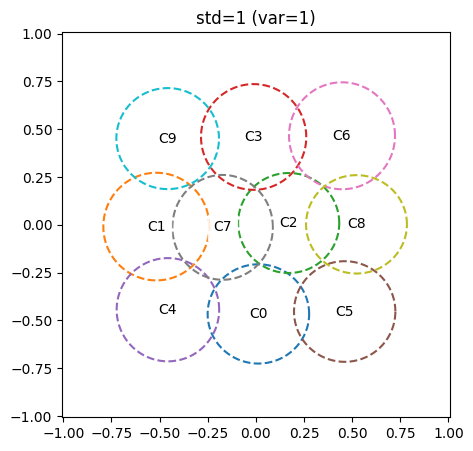

In [265]:
ano(1)

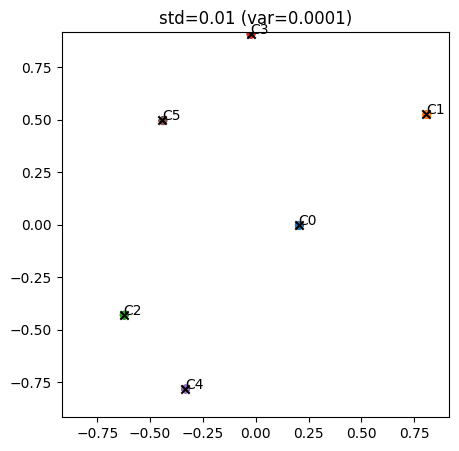

In [166]:
ano(0.01)